# Konkan Canara - LSTM + U-Net Hybrid Model for Total Precipitation Prediction (8-Step Input Sequence)

In [1]:
# Importing the required libraries
import numpy as np
import joblib
import importlib
    
import random
import gc

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

import KC_Data_Preprocessing as KCD
import Baseline_Model_Definitions as BMD
import Baseline_Model_Utils as BMU
import UNet_Model_Definitions as UMD
import UNet_Model_Utils as UMU

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 4060 Laptop GPU', major=8, minor=9, total_memory=8187MB, multi_processor_count=24, uuid=a73fa0eb-512f-ffe4-cf94-f2e7b26c980c, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=32MB)

In [5]:
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

In [6]:
torch.cuda.init()

In [7]:
gc.collect()
torch.cuda.empty_cache()

## Data Loading and Preprocessing

In [8]:
importlib.reload(KCD);

In [9]:
feature_scaler = joblib.load('feature_scaler_tp.pkl')
target_scaler = joblib.load('target_scaler_tp.pkl')

SEQ_LEN = 8

data = KCD.prepare_konkan_data(
    file_path='KC_6H_2001-2025_Final.csv', 
    feature_scaler=feature_scaler, 
    target_scaler=target_scaler, 
    seq_len=SEQ_LEN, 
    target_variable='tp'
)

X_train, y_train = data['train']
X_val, y_val = data['val']

height = data['meta']['height']
width = data['meta']['width']
num_channels = data['meta']['channels'] 
feature_names = data['meta']['feature_names']

print(f'X_train shape: {X_train.shape} (2001-2018)')
print(f'X_val shape: {X_val.shape} (2019-2020)')

X_train shape: (26288, 8, 32, 12, 8) (2001-2018)
X_val shape: (2924, 8, 32, 12, 8) (2019-2020)


In [10]:
feature_names

['msl', 'sst', 'u10', 'v10', 'ws', 't2m', 'rh', 'tp']

In [11]:
height, width, num_channels

(32, 12, 8)

### Reshaping the data and preparing DataLoaders

In [12]:
# Reshape X_train from (N, SEQ_LEN, 32, 12, 8) to (N, SEQ_LEN, 32 * 12 * 8)
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1) 
y_train_flat = y_train.reshape(y_train.shape[0], -1)

X_val_lstm = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
y_val_flat = y_val.reshape(y_val.shape[0], -1)

print(f'--- LSTM Input Shapes ---')
print(f'Train: X={X_train_lstm.shape} (Batch, Seq, Features), y={y_train_flat.shape}')
print(f'Val:   X={X_val_lstm.shape}, y={y_val_flat.shape}')

--- LSTM Input Shapes ---
Train: X=(26288, 8, 3072) (Batch, Seq, Features), y=(26288, 384)
Val:   X=(2924, 8, 3072), y=(2924, 384)


In [13]:
lstm_dataset_train = TensorDataset(torch.from_numpy(X_train_lstm).float().to(device), 
                                 torch.from_numpy(y_train_flat).float().to(device))
lstm_dataset_val = TensorDataset(torch.from_numpy(X_val_lstm).float().to(device), 
                               torch.from_numpy(y_val_flat).float().to(device))

BATCH_SIZE_LSTM = 128

lstm_train_loader = DataLoader(lstm_dataset_train, batch_size=BATCH_SIZE_LSTM, shuffle=True, pin_memory=False)
lstm_val_loader = DataLoader(lstm_dataset_val, batch_size=BATCH_SIZE_LSTM, shuffle=False, pin_memory=False)

## PyTorch LSTM Baseline

In [14]:
importlib.reload(BMD);
importlib.reload(BMU);

In [15]:
INPUT_SIZE_LSTM = num_channels * height * width  
HIDDEN_SIZES = [16]
OUTPUT_SIZE_LSTM = height * width

lstm_model = BMD.LSTMModel(
    input_features=INPUT_SIZE_LSTM,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE_LSTM
).to(device)

In [16]:
summary(lstm_model, input_size=(BATCH_SIZE_LSTM, SEQ_LEN, INPUT_SIZE_LSTM))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [128, 384]                --
├─LSTM: 1-1                              [128, 8, 16]              197,760
├─Linear: 1-2                            [128, 384]                6,528
Total params: 204,288
Trainable params: 204,288
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 203.34
Input size (MB): 12.58
Forward/backward pass size (MB): 0.52
Params size (MB): 0.82
Estimated Total Size (MB): 13.92

In [17]:
lstm_loss_fn = nn.MSELoss()
lstm_optimizer = BMU.lg_optimizer(lstm_model)
LSTM_EPOCHS = 50

In [18]:
torch.cuda.synchronize()
start_event.record()

train_losses_lstm, val_losses_lstm = BMU.lg_train_model(
    lstm_model, 
    lstm_train_loader, 
    lstm_val_loader, 
    lstm_optimizer,    
    lstm_loss_fn,      
    epochs=LSTM_EPOCHS,
)

end_event.record()
torch.cuda.synchronize()

Epoch 1/50 | Train Loss: 0.023628 | Val Loss: 0.014329
  --> Saved Best Weights


Epoch 2/50 | Train Loss: 0.008205 | Val Loss: 0.007969
  --> Saved Best Weights


Epoch 3/50 | Train Loss: 0.006279 | Val Loss: 0.007281
  --> Saved Best Weights


Epoch 4/50 | Train Loss: 0.005917 | Val Loss: 0.007033
  --> Saved Best Weights


Epoch 5/50 | Train Loss: 0.005599 | Val Loss: 0.006619
  --> Saved Best Weights


...

Epoch 46/50 | Train Loss: 0.004425 | Val Loss: 0.005389
  --> Saved Best Weights


Epoch 47/50 | Train Loss: 0.004437 | Val Loss: 0.005631


Epoch 48/50 | Train Loss: 0.004434 | Val Loss: 0.005389


Epoch 49/50 | Train Loss: 0.004419 | Val Loss: 0.005370
  --> Saved Best Weights


Epoch 50/50 | Train Loss: 0.004403 | Val Loss: 0.005354
  --> Saved Best Weights


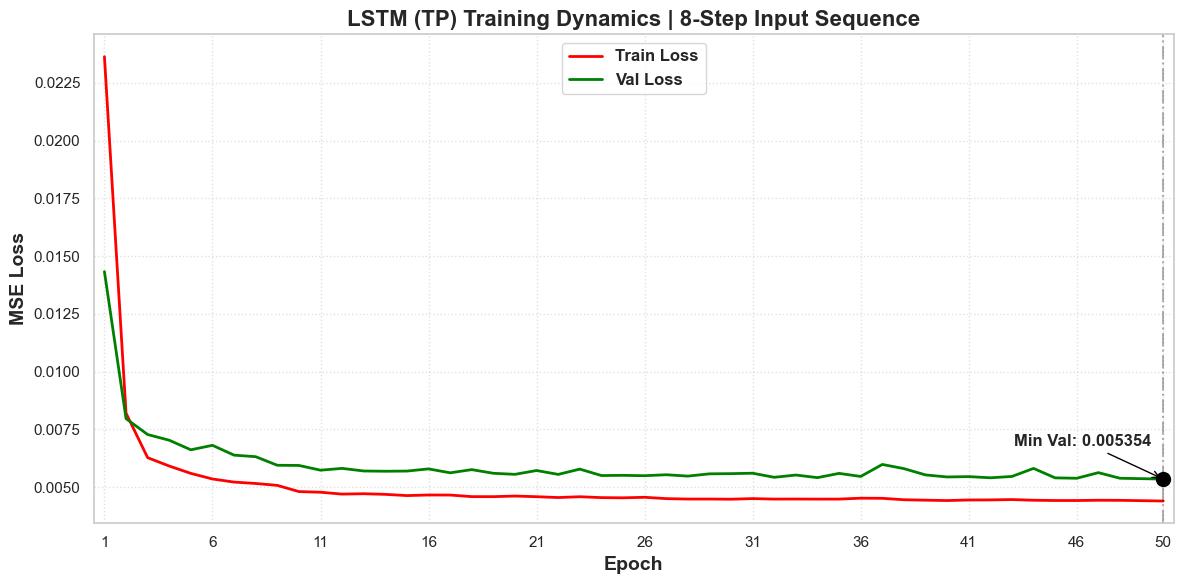

In [19]:
BMU.plot_training_dynamics(
    train_losses_lstm, val_losses_lstm, loss_name='MSE Loss', model_name='LSTM (TP)', seq_len=SEQ_LEN
)

In [20]:
elapsed_time_lstm = start_event.elapsed_time(end_event)
lstm_duration = elapsed_time_lstm / 1000

minutes, seconds = divmod(lstm_duration, 60)

if minutes > 0:
    print(f'LSTM Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'LSTM Training Time: {seconds:.2f} seconds')

LSTM Training Time: 40.05 seconds


In [21]:
torch.save(lstm_model.state_dict(), 'LSTM_8S_TP.pth');

### Generating hints and data loaders for the U-Net models

In [22]:
lstm_model.eval()

with torch.inference_mode():
    X_train_lstm_tensor = torch.as_tensor(X_train_lstm, device=device, dtype=torch.float32)
    X_val_lstm_tensor = torch.as_tensor(X_val_lstm, device=device, dtype=torch.float32)

    lstm_hint_train_flat = lstm_model(X_train_lstm_tensor)
    lstm_hint_val_flat = lstm_model(X_val_lstm_tensor)

# Reshape hints back to spatial grids
lstm_hint_train_tensor = lstm_hint_train_flat.view(-1, 1, height, width)
lstm_hint_val_tensor = lstm_hint_val_flat.view(-1, 1, height, width)

# Get the last timestep (T-1) raw features to concatenate
X_train_last = torch.from_numpy(X_train[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)
X_val_last = torch.from_numpy(X_val[:, -1, :, :, :]).float().to(device).permute(0, 3, 1, 2)

# Concatenating Features + Hint Channel (N, 8+1, 32, 12)
hybrid_X_train_tensor = torch.cat([X_train_last, lstm_hint_train_tensor], dim=1)
hybrid_X_val_tensor = torch.cat([X_val_last, lstm_hint_val_tensor], dim=1)

y_train_tensor = torch.from_numpy(y_train).float().to(device).permute(0, 3, 1, 2)
y_val_tensor = torch.from_numpy(y_val).float().to(device).permute(0, 3, 1, 2)

print(f'Hybrid Input Shapes: Train={hybrid_X_train_tensor.shape}, Val={hybrid_X_val_tensor.shape}')

Hybrid Input Shapes: Train=torch.Size([26288, 9, 32, 12]), Val=torch.Size([2924, 9, 32, 12])


In [23]:
BATCH_SIZE_UNET = 128

unet_train_loader = DataLoader(
    TensorDataset(hybrid_X_train_tensor, y_train_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=True,    
    pin_memory=False
)

unet_val_loader = DataLoader(
    TensorDataset(hybrid_X_val_tensor, y_val_tensor), 
    batch_size=BATCH_SIZE_UNET, 
    shuffle=False,
    pin_memory=False
)

## U-Net Models

In [24]:
importlib.reload(UMU);
importlib.reload(UMD);

In [25]:
unet_loss_fn = torch.nn.GaussianNLLLoss(eps=1e-6, full=True, reduction='none')

In [ ]:
INPUT_CHANNELS_UNET = num_channels + 1
OUTPUT_CHANNELS_UNET = 2
UNET_EPOCHS = 50

### Standard U-Net

In [27]:
hybrid_model1 = UMD.Standard_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model1)

In [28]:
summary(hybrid_model1, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width)) 

Layer (type:depth-idx)                        Output Shape              Param #
Standard_UNet                                 [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses1, val_losses1, lr_history1 = UMU.train_model(
    hybrid_model1, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: 0.130540 | Val Loss: -0.087229 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.270689 | Val Loss: -0.446210 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.661041 | Val Loss: -0.844148 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.065231 | Val Loss: -1.193097 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.381756 | Val Loss: -1.372032 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.293237 | Val Loss: -2.439550 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.292893 | Val Loss: -2.439741 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.293947 | Val Loss: -2.439379 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.294434 | Val Loss: -2.439793 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.294988 | Val Loss: -2.439608 | LR: 1.00e-08


In [31]:
elapsed_time_unet1 = start_event.elapsed_time(end_event)
unet_duration1 = elapsed_time_unet1 / 1000

minutes, seconds = divmod(unet_duration1, 60)

if minutes > 0:
    print(f'Standard U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Standard U-Net Training Time: {seconds:.2f} seconds')

Standard U-Net Training Time: 6 minutes and 20.75 seconds


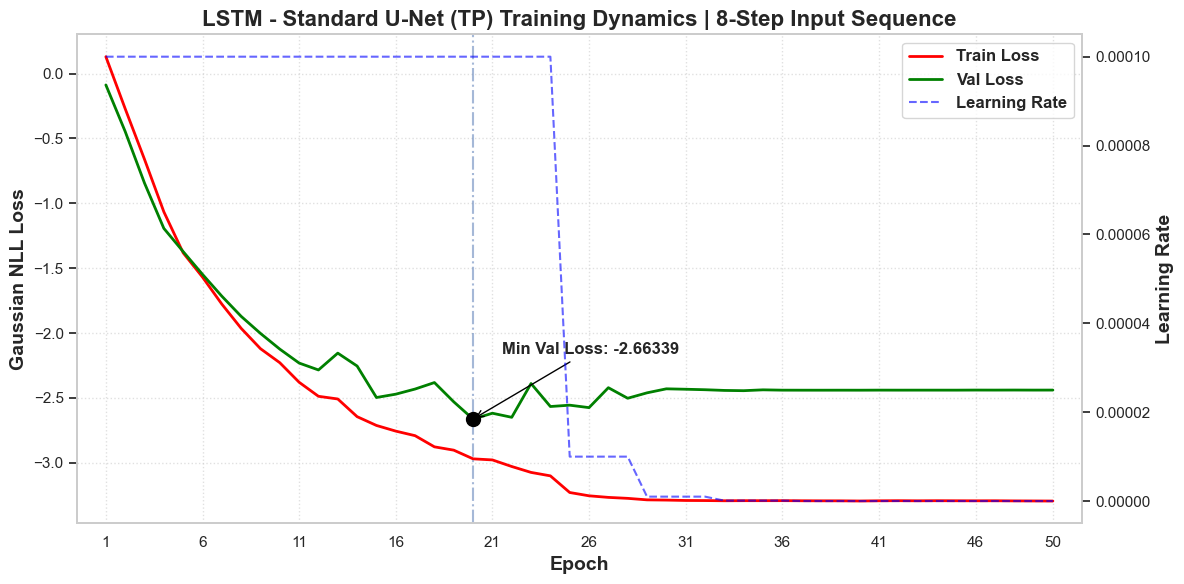

In [32]:
UMU.plot_training_dynamics(train_losses1, val_losses1, lr_history1, 
                       'LSTM - Standard U-Net (TP)', SEQ_LEN)

In [33]:
torch.save(hybrid_model1.state_dict(), 'LSTM_Standard_U-Net_Hybrid_TP_8S.pth')

In [34]:
del hybrid_model1, 
del optimizer
del scheduler

In [35]:
gc.collect()
torch.cuda.empty_cache()

### Residual U-Net

In [36]:
hybrid_model2 = UMD.Residual_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model2)

In [37]:
summary(hybrid_model2, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Residual_UNet                                 [128, 2, 32, 12]          --
├─ResidualDoubleConv: 1-1                     [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    └─Sequential: 2-2                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-6                       [128, 64, 32, 12]         576
│    │    └─GroupNorm: 3-7                    [128, 64, 32, 12]         128
│    └─ReLU: 2-3                              [128, 64, 32, 12]         --
├─BaseDow

In [38]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses2, val_losses2, lr_history2 = UMU.train_model(
    hybrid_model2, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.699261 | Val Loss: -1.142401 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -1.388711 | Val Loss: -1.400477 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -1.669476 | Val Loss: -1.696343 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.940267 | Val Loss: -1.899915 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -2.157602 | Val Loss: -2.005624 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.397258 | Val Loss: -1.659386 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.396972 | Val Loss: -1.659690 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.396223 | Val Loss: -1.658977 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.396087 | Val Loss: -1.658940 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.397350 | Val Loss: -1.658981 | LR: 1.00e-08


In [40]:
elapsed_time_unet2 = start_event.elapsed_time(end_event)
unet_duration2 = elapsed_time_unet2 / 1000

minutes, seconds = divmod(unet_duration2, 60)

if minutes > 0:
    print(f'Residual U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Residual U-Net Training Time: {seconds:.2f} seconds')

Residual U-Net Training Time: 7 minutes and 2.73 seconds


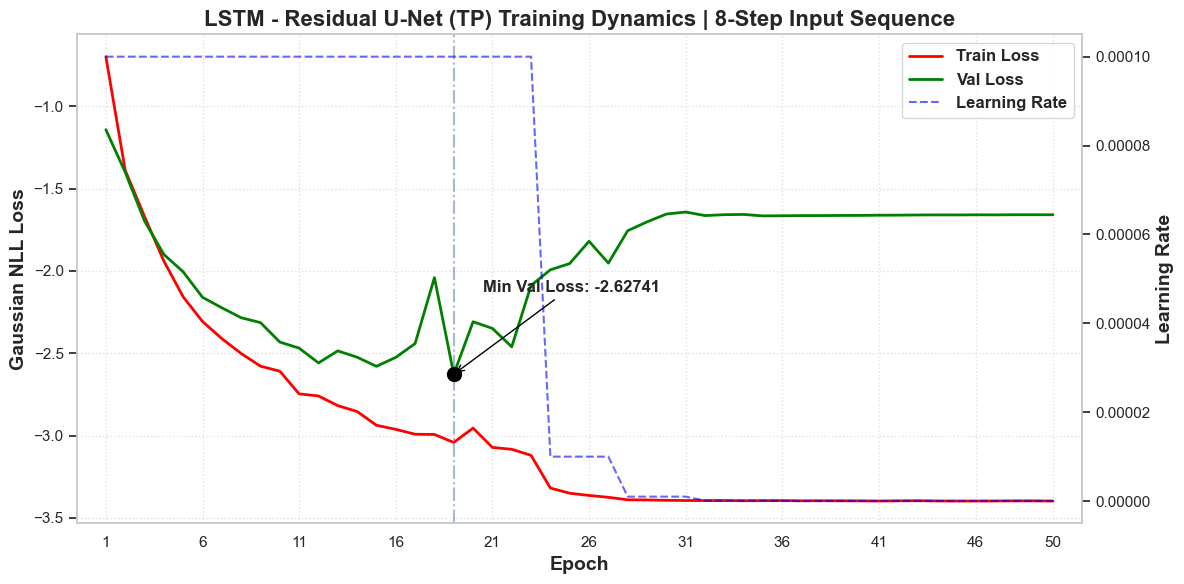

In [41]:
UMU.plot_training_dynamics(train_losses2, val_losses2, lr_history2, 
                       'LSTM - Residual U-Net (TP)', SEQ_LEN)

In [42]:
torch.save(hybrid_model2.state_dict(), 'LSTM_Residual_U-Net_Hybrid_TP_8S.pth')

In [43]:
del hybrid_model2, 
del optimizer
del scheduler

In [44]:
gc.collect()
torch.cuda.empty_cache()

### Attention U-Net

In [45]:
hybrid_model3 = UMD.Attention_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model3)

In [46]:
summary(hybrid_model3, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                        Output Shape              Param #
Attention_UNet                                [128, 2, 32, 12]          --
├─BaseDoubleConv: 1-1                         [128, 64, 32, 12]         --
│    └─Sequential: 2-1                        [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                       [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                         [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                       [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                    [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                         [128, 64, 32, 12]         --
├─BaseDown: 1-2                               [128, 128, 16, 6]         --
│    └─Sequential: 2-2                        [128, 128, 16, 6]         --
│    │    └─LPPool2d: 3-7                     [128, 64, 16, 6]          --
│    │    └

In [47]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses3, val_losses3, lr_history3 = UMU.train_model(
    hybrid_model3, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.059571 | Val Loss: -0.313285 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.521060 | Val Loss: -0.697530 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.909125 | Val Loss: -1.057476 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.255390 | Val Loss: -1.314108 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.489457 | Val Loss: -1.434760 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.276014 | Val Loss: -2.411548 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.276604 | Val Loss: -2.411554 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.275193 | Val Loss: -2.411350 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.275648 | Val Loss: -2.411061 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.275261 | Val Loss: -2.411112 | LR: 1.00e-08


In [49]:
elapsed_time_unet3 = start_event.elapsed_time(end_event)
unet_duration3 = elapsed_time_unet3 / 1000

minutes, seconds = divmod(unet_duration3, 60)

if minutes > 0:
    print(f'Attention U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Attention U-Net Training Time: {seconds:.2f} seconds')

Attention U-Net Training Time: 7 minutes and 18.28 seconds


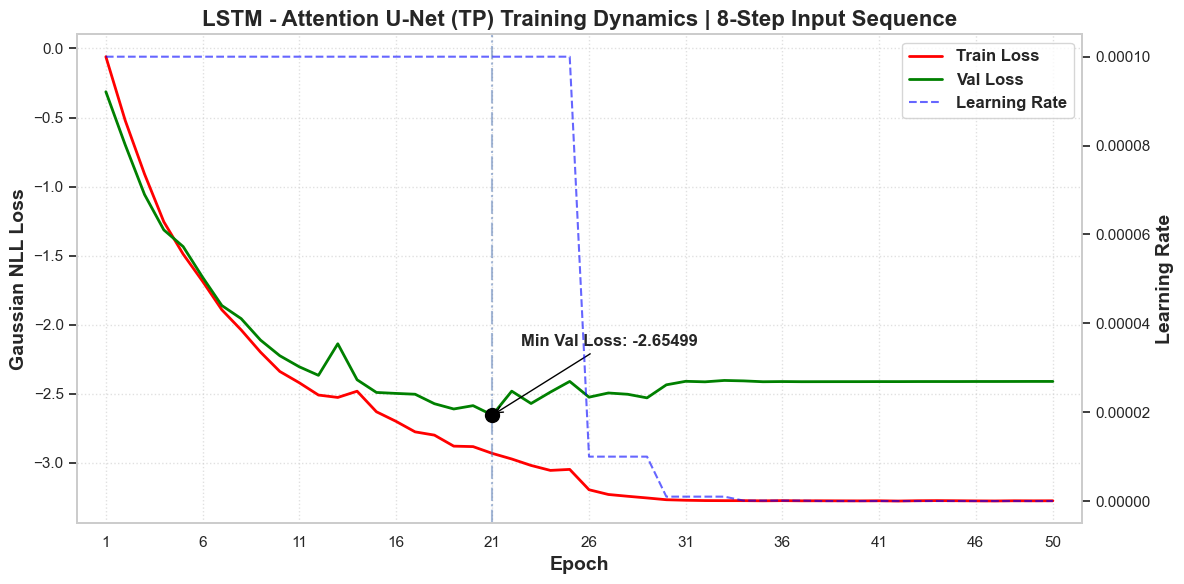

In [50]:
UMU.plot_training_dynamics(train_losses3, val_losses3, lr_history3, 
                       'LSTM - Attention U-Net (TP)', SEQ_LEN)

In [51]:
torch.save(hybrid_model3.state_dict(), 'LSTM_Attention_U-Net_Hybrid_TP_8S.pth')

In [52]:
del hybrid_model3
del optimizer
del scheduler

In [53]:
gc.collect()
torch.cuda.empty_cache()

### CBAM (Convolution Block Attention Module) U-Net

In [54]:
hybrid_model4 = UMD.CBAM_UNet(n_channels=INPUT_CHANNELS_UNET, n_out=OUTPUT_CHANNELS_UNET).to(device)
optimizer, scheduler = UMU.get_optimizer_and_scheduler(hybrid_model4)

In [55]:
summary(hybrid_model4, input_size=(BATCH_SIZE_UNET, INPUT_CHANNELS_UNET, height, width))

Layer (type:depth-idx)                             Output Shape              Param #
CBAM_UNet                                          [128, 2, 32, 12]          --
├─CBAMDoubleConv: 1-1                              [128, 64, 32, 12]         --
│    └─Sequential: 2-1                             [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-1                            [128, 64, 32, 12]         5,184
│    │    └─GroupNorm: 3-2                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-3                              [128, 64, 32, 12]         --
│    │    └─Conv2d: 3-4                            [128, 64, 32, 12]         36,864
│    │    └─GroupNorm: 3-5                         [128, 64, 32, 12]         128
│    │    └─ReLU: 3-6                              [128, 64, 32, 12]         --
│    └─ChannelAttention: 2-2                       [128, 64, 1, 1]           --
│    │    └─AdaptiveAvgPool2d: 3-7                 [128, 64, 1, 1]           --
│    │    └─Sequential: 3-

In [56]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
torch.cuda.synchronize()
start_event.record()

train_losses4, val_losses4, lr_history4 = UMU.train_model(
    hybrid_model4, unet_train_loader, unet_val_loader, optimizer, scheduler, 
    unet_loss_fn, epochs=UNET_EPOCHS, device=device
)

end_event.record()
torch.cuda.synchronize()

Epoch 1 | Train Loss: -0.001124 | Val Loss: -0.234879 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 2 | Train Loss: -0.434528 | Val Loss: -0.615780 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 3 | Train Loss: -0.827012 | Val Loss: -0.979491 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 4 | Train Loss: -1.196327 | Val Loss: -1.281820 | LR: 1.00e-04
  --> Saved Best Weights


Epoch 5 | Train Loss: -1.457880 | Val Loss: -1.403754 | LR: 1.00e-04
  --> Saved Best Weights


...

Epoch 46 | Train Loss: -3.257531 | Val Loss: -2.536886 | LR: 1.00e-08


Epoch 47 | Train Loss: -3.259906 | Val Loss: -2.536708 | LR: 1.00e-08


Epoch 48 | Train Loss: -3.259438 | Val Loss: -2.536540 | LR: 1.00e-08


Epoch 49 | Train Loss: -3.258715 | Val Loss: -2.536816 | LR: 1.00e-08


Epoch 50 | Train Loss: -3.258351 | Val Loss: -2.536336 | LR: 1.00e-08


In [58]:
elapsed_time_unet4 = start_event.elapsed_time(end_event)
unet_duration4 = elapsed_time_unet4 / 1000

minutes, seconds = divmod(unet_duration4, 60)

if minutes > 0:
    print(f'CBAM U-Net Training Time: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'CBAM U-Net Training Time: {seconds:.2f} seconds')

CBAM U-Net Training Time: 7 minutes and 15.93 seconds


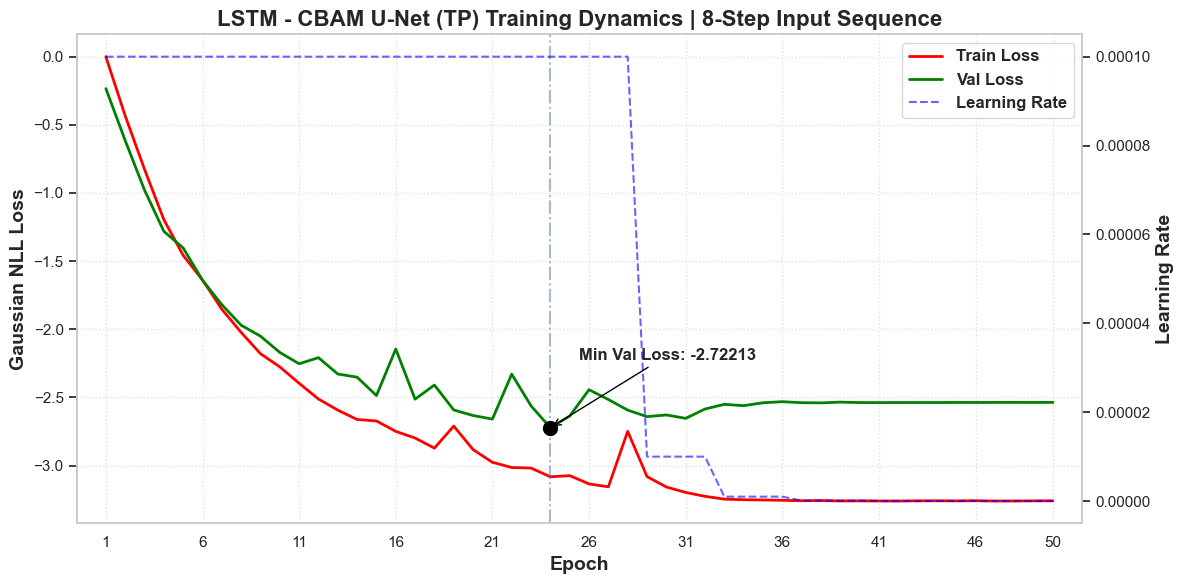

In [59]:
UMU.plot_training_dynamics(train_losses4, val_losses4, lr_history4, 
                       'LSTM - CBAM U-Net (TP)', SEQ_LEN)

In [60]:
torch.save(hybrid_model4.state_dict(), 'LSTM_CBAM_U-Net_Hybrid_TP_8S.pth')

In [61]:
del hybrid_model4 
del optimizer
del scheduler

In [62]:
gc.collect()
torch.cuda.empty_cache()

## Total Training Time for Each Hybrid Model

In [63]:
total_duration1 = lstm_duration + unet_duration1
minutes, seconds = divmod(total_duration1, 60)

if minutes > 0:
    print(f'Total Training Time for LSTM - Standard U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for LSTM - Standard U-Net: {seconds:.2f} seconds')

Total Training Time for LSTM - Standard U-Net: 7 minutes and 0.80 seconds


In [64]:
total_duration2 = lstm_duration + unet_duration2
minutes, seconds = divmod(total_duration2, 60)

if minutes > 0:
    print(f'Total Training Time for LSTM - Residual U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for LSTM - Residual U-Net: {seconds:.2f} seconds')

Total Training Time for LSTM - Residual U-Net: 7 minutes and 42.79 seconds


In [65]:
total_duration3 = lstm_duration + unet_duration3
minutes, seconds = divmod(total_duration3, 60)

if minutes > 0:
    print(f'Total Training Time for LSTM - Attention U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for LSTM - Attention U-Net: {seconds:.2f} seconds')

Total Training Time for LSTM - Attention U-Net: 7 minutes and 58.33 seconds


In [66]:
total_duration4 = lstm_duration + unet_duration4
minutes, seconds = divmod(total_duration4, 60)

if minutes > 0:
    print(f'Total Training Time for LSTM - CBAM U-Net: {int(minutes)} minutes and {seconds:.2f} seconds')
else:
    print(f'Total Training Time for LSTM - CBAM U-Net: {seconds:.2f} seconds')

Total Training Time for LSTM - CBAM U-Net: 7 minutes and 55.99 seconds


***